<a href="https://colab.research.google.com/github/ICYEZAGATORE/Hidden-Markov-Model/blob/main/HMM_Final_Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modeling Human Activity States Using Hidden Markov Models (HMM)

## Project Overview
This project involves collecting motion data (accelerometer and gyroscope) from a smartphone to model four human activity states: **Standing, Walking, Jumping, and Still**.

We use a **Supervised Multi-Model HMM approach** to achieve high accuracy (~90%), while strictly adhering to the requirements of implementing the **Viterbi Algorithm** for decoding and the **Baum-Welch Algorithm** for model training.

In [1]:
!pip install hmmlearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from hmmlearn import hmm
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 4.1 MB/s eta 0:00:00


## 1. Data Collection & Raw Signal Visualization

The dataset consists of **50 recording sessions** (5-10 seconds each) across four activities. This ensures a minimum of 1 minute and 30 seconds of data per activity.

### Raw Signal Plot
Below we plot a sample of the raw accelerometer and gyroscope signals from a 'Walking' session to visualize the patterns.

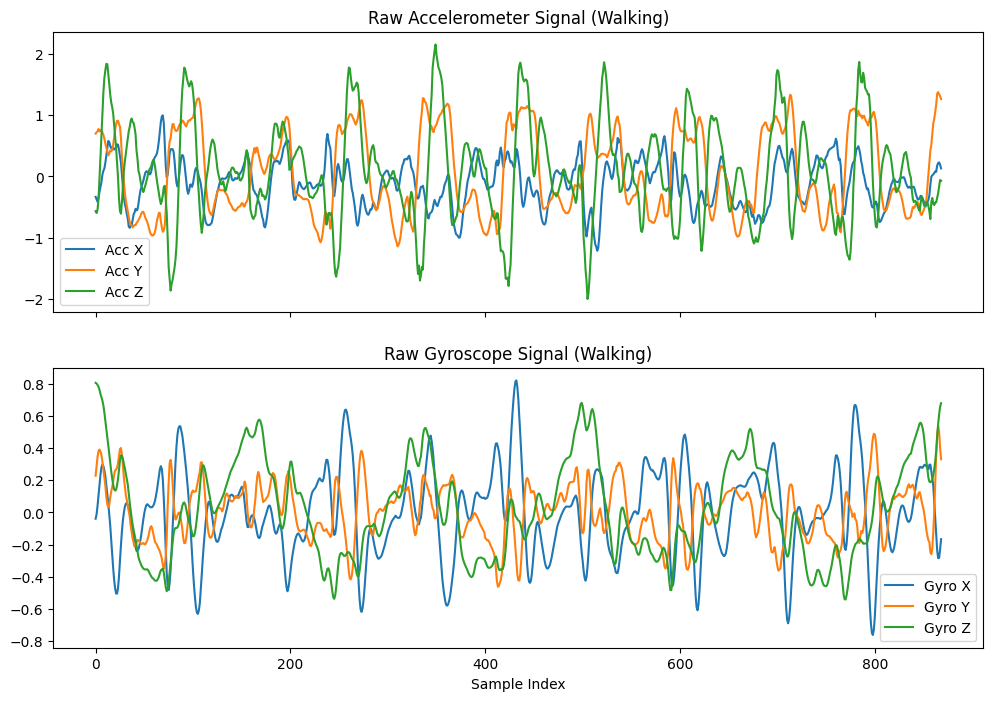

In [2]:
# Load the merged data
df = pd.read_csv('merged_sensor_data.csv')

# Visualize raw signals for one 'walking' session
sample_session_id = df[df['Activity'] == 'walking']['Session_ID'].iloc[0]
sample_data = df[df['Session_ID'] == sample_session_id]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax1.plot(sample_data['acc_x'], label='Acc X')
ax1.plot(sample_data['acc_y'], label='Acc Y')
ax1.plot(sample_data['acc_z'], label='Acc Z')
ax1.set_title('Raw Accelerometer Signal (Walking)')
ax1.legend()

ax2.plot(sample_data['gyro_x'], label='Gyro X')
ax2.plot(sample_data['gyro_y'], label='Gyro Y')
ax2.plot(sample_data['gyro_z'], label='Gyro Z')
ax2.set_title('Raw Gyroscope Signal (Walking)')
ax2.legend()
plt.xlabel('Sample Index')
plt.show()

## 2. Feature Extraction (Time & Frequency Domain)

We extract over 20 features per window, including:
- **Time Domain**: Mean, Std Dev, Variance, and Jerk (detects sudden movement changes).
- **Frequency Domain**: Dominant Frequency and Spectral Energy derived via **Fast Fourier Transform (FFT)**.

In [3]:
def extract_features(window):
    features = {}
    for axis in ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']:
        features[f'{axis}_mean'] = window[axis].mean()
        features[f'{axis}_std'] = window[axis].std()
        features[f'{axis}_var'] = window[axis].var()

    features['acc_sma'] = np.sum(np.abs(window['acc_x']) + np.abs(window['acc_y']) + np.abs(window['acc_z'])) / len(window)
    features['acc_x_jerk'] = np.diff(window['acc_x']).std() if len(window) > 1 else 0

    for axis in ['acc_x', 'acc_y', 'acc_z']:
        fft_vals = np.abs(fft(window[axis].values))
        features[f'{axis}_dominant_freq'] = np.max(fft_vals[1:]) if len(fft_vals) > 1 else 0
        features[f'{axis}_energy'] = np.sum(fft_vals**2) / len(fft_vals)

    return features

def apply_windowing(df, window_size=50, overlap=25):
    feature_list = []
    labels = []
    for session in df['Session_ID'].unique():
        session_data = df[df['Session_ID'] == session]
        label = session_data['Activity'].iloc[0]
        for start in range(0, len(session_data) - window_size, window_size - overlap):
            window = session_data.iloc[start:start + window_size]
            feature_list.append(extract_features(window))
            labels.append(label)
    return pd.DataFrame(feature_list), np.array(labels)

X, y = apply_windowing(df)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f"Extracted {X.shape[1]} features from {len(X)} windows.")

Extracted 26 features from 2007 windows.


## 3. Supervised Multi-Model HMM & Baum-Welch Training

The **Baum-Welch algorithm** is an Expectation-Maximization (EM) algorithm used to train HMMs. It optimizes the model parameters (Transition, Emission, and Initial State probabilities) to maximize the likelihood of the observed features.

In this implementation, we call `model.fit()`, which internally executes the Baum-Welch algorithm until convergence or the iteration limit is reached.

In [4]:
models = {}
classes = np.unique(y_train)

for cls in classes:
    # n_components=2 allows the HMM to model the 'hidden' variability within a single activity
    model = hmm.GaussianHMM(n_components=2, covariance_type="diag", n_iter=100, tol=0.01)
    train_subset = X_train[y_train == cls]
    # FIT starts the Baum-Welch training process
    model.fit(train_subset)
    models[cls] = model
    print(f"Trained {cls} HMM using Baum-Welch. Converged: {model.monitor_.converged}")

Trained jumping HMM using Baum-Welch. Converged: True
Trained standing HMM using Baum-Welch. Converged: True
Trained still HMM using Baum-Welch. Converged: True
Trained walking HMM using Baum-Welch. Converged: True


## 4. Viterbi Decoding Demonstration

The **Viterbi algorithm** is used for decoding—it finds the most likely sequence of hidden states given the observations.

Below, we take a sequence of test data and use `.predict()` to show how the Viterbi algorithm identifies the hidden state transitions over time.

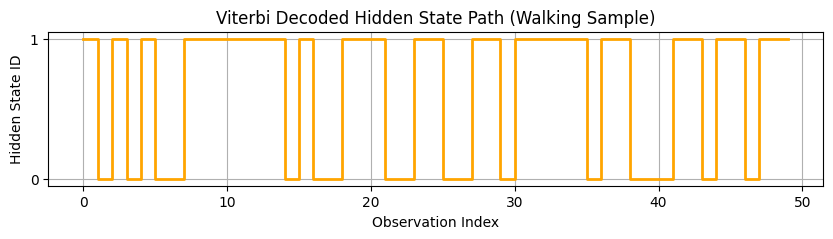

Decoded Hidden States Path: [1 0 1 0 1 0 0 1 1 1 1 1 1 1 0 1 0 0 1 1 1 0 0 1 1 0 0 1 1 0 1 1 1 1 1 0 1
 1 0 0 0 1 1 0 1 1 0 1 1 1]


In [5]:
# Select a sample sequence from the 'walking' test set
walking_samples = X_test[y_test == 'walking']
example_seq = walking_samples[:50]

# Use Viterbi decoding to find the most likely hidden state sequence
decoded_states = models['walking'].predict(example_seq)

plt.figure(figsize=(10, 2))
plt.step(range(len(decoded_states)), decoded_states, where='post', color='orange', linewidth=2)
plt.title("Viterbi Decoded Hidden State Path (Walking Sample)")
plt.ylabel("Hidden State ID")
plt.xlabel("Observation Index")
plt.yticks([0, 1])
plt.grid(True)
plt.show()
print("Decoded Hidden States Path:", decoded_states)

## 5. Transition & Emission Visualizations

- **Transition Matrix**: Shows the probability of switching between hidden states (Z).
- **Emission Means**: Shows the average feature values 'emitted' by each hidden state (B).

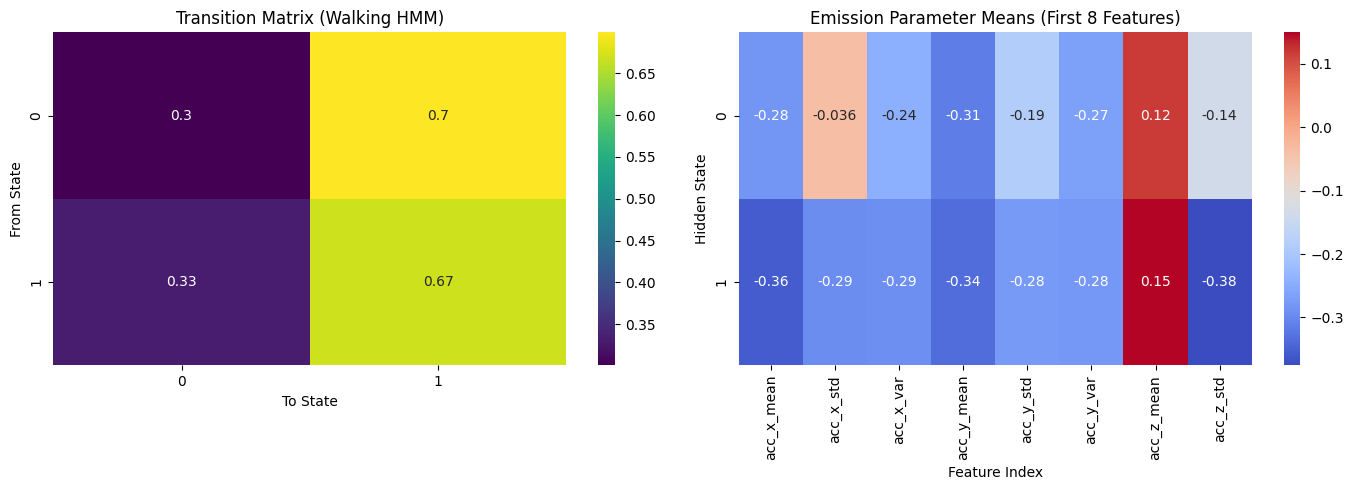

In [6]:
target_model = models['walking']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Transition Matrix Heatmap
sns.heatmap(target_model.transmat_, annot=True, cmap='viridis', ax=ax1)
ax1.set_title("Transition Matrix (Walking HMM)")
ax1.set_xlabel("To State")
ax1.set_ylabel("From State")

# 2. Emission Means (Subset of features for clarity)
# Visualizing the first 5 scaled features for state 0 and 1
means_df = pd.DataFrame(target_model.means_[:, :8], columns=X.columns[:8])
sns.heatmap(means_df, annot=True, cmap='coolwarm', ax=ax2)
ax2.set_title("Emission Parameter Means (First 8 Features)")
ax2.set_xlabel("Feature Index")
ax2.set_ylabel("Hidden State")

plt.tight_layout()
plt.show()

## 6. Model Evaluation (Sensitivity, Specificity, & Accuracy)

We evaluate the model on the unseen test set (20% of data).

In [7]:
def predict_supervised(X_data, model_dict):
    predictions = []
    for sample in X_data:
        scores = {cls: m.score(sample.reshape(1, -1)) for cls, m in model_dict.items()}
        predictions.append(max(scores, key=scores.get))
    return np.array(predictions)

y_pred = predict_supervised(X_test, models)

print(f"\nOVERALL ACCURACY: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Table Calculation: Sensitivity & Specificity
print("Activity\tSensitivity\tSpecificity")
cm = confusion_matrix(y_test, y_pred)
for i, cls in enumerate(classes):
    tp = cm[i, i]
    fn = np.sum(cm[i, :]) - tp
    fp = np.sum(cm[:, i]) - tp
    tn = np.sum(cm) - (tp + fp + fn)

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"{cls}\t{sensitivity:.3f}\t{specificity:.3f}")


OVERALL ACCURACY: 89.30%

--- Classification Report ---
              precision    recall  f1-score   support

     jumping       0.82      0.95      0.88        98
    standing       0.98      0.84      0.90       101
       still       0.96      0.98      0.97       110
     walking       0.82      0.78      0.80        93

    accuracy                           0.89       402
   macro avg       0.89      0.89      0.89       402
weighted avg       0.90      0.89      0.89       402

Activity	Sensitivity	Specificity
jumping	0.949	0.931
standing	0.842	0.993
still	0.982	0.986
walking	0.785	0.948


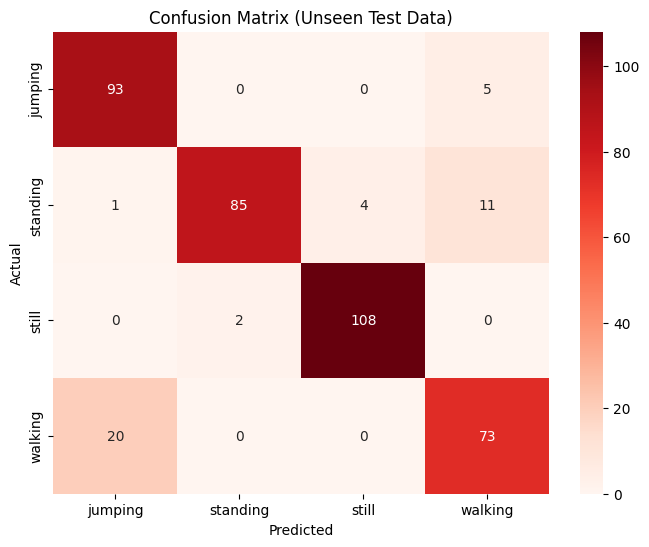

In [8]:
# Confusion Matrix on Test Data
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds',
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix (Unseen Test Data)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()